# TS4: Primeras nociones de estimación espectral (2025)

## Alumnos: Facundo Carranza

## RESUMEN 

Este trabajo tiene como objetivo estudiar el comportamiento de estimadores espectrales aplicados a señales sinusoidales contaminadas con ruido blanco aditivo. En particular, se analiza cómo distintas ventanas de análisis afectan la estimación de parámetros fundamentales como la amplitud y la frecuencia de la señal, bajo diferentes condiciones de relación señal-ruido (SNR).

Se parte de la generación de señales sintéticas con frecuencia aleatoria centrada en un valor conocido, y se simulan múltiples realizaciones para evaluar estadísticamente el desempeño de los estimadores. Se aplican ventanas clásicas como Rectangular, Flattop, Blackman-Harris y Hann, y se calcula la Transformada Discreta de Fourier (DFT) con y sin zero-padding para mejorar la resolución espectral.

A lo largo del trabajo se evalúan métricas clave como el sesgo y la varianza de los estimadores de amplitud y frecuencia, permitiendo comparar el impacto de cada ventana en la precisión de las estimaciones. Además, se visualizan los resultados mediante histogramas y gráficos de densidad espectral de potencia (PSD), lo que facilita la interpretación de los efectos del ventaneo y del nivel de ruido.
Este estudio no solo permite validar conceptos teóricos como el desparramo espectral y la influencia del SNR, sino que también ofrece herramientas prácticas para el diseño de sistemas de medición y análisis en entornos ruidosos.


## INTRODUCCION 

## ESTIMADORES ESPECTRALES 

En el procesamiento digital de señales, los estimadores espectrales permiten extraer parámetros clave de señales periódicas a partir de su representación en frecuencia. Mediante la Transformada Discreta de Fourier (DFT), es posible analizar el contenido espectral de una señal y estimar características como la amplitud y la frecuencia de sus componentes sinusoidales.

## Estimador de amplitud espectral

La amplitud de una senoidal puede estimarse como el valor máximo del módulo del espectro en la frecuencia esperada. Este estimador se ve afectado por el tipo de ventana utilizada, el nivel de ruido (SNR) y la resolución espectral. Para mejorar la precisión, se suele aplicar zero-padding y normalizar por el promedio de la ventana.

## Estimador de frecuencia espectral

La frecuencia se estima como el índice (o frecuencia) donde el espectro alcanza su máximo valor. Este estimador es sensible al desparramo espectral y a la resolución de la DFT, por lo que el uso de ventanas adecuadas y técnicas como el zero-padding pueden mejorar su desempeño.


Ambos estimadores se evalúan estadísticamente mediante el cálculo de sesgo (diferencia entre el valor estimado promedio y el valor real) y varianza (dispersión de las estimaciones), lo que permite comparar su robustez frente al ruido y la elección de ventana.


# Declaracion de senal y variables 

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft
import scipy.signal.windows as window
import scipy.stats as st


def señal (tt, frec, amp, SNR, R, fase=0, v_medio=0):

    N = len(tt)
    s = amp*np.sin(2*np.pi*frec*tt + fase) + v_medio
    if SNR == None:
      return s

    P_signal = np.mean (s)
    P_noise  = P_signal / (10**(SNR/10))
    ruido_mat = np.random.normal (0, np.sqrt(P_noise), size=(N,R))
    return s + ruido_mat

fs = 1000
N = 1000
df = fs/N
R = 200
ff = np.arange (N) * df
ff_zp = fs * np.arange (10*N) / (10*N)


tt = np.arange (N) / fs                       
tt_col = tt.reshape (N, 1)                 
tt_mat = np.tile (tt_col, (1, R))            

frec_rand = np.random.uniform (-2, 2, R)     
frec = (N/4 + frec_rand) * df              
frec_fila = frec.reshape (1, R)               
frec_mat = np.tile (frec_fila, (N, 1))       

# Generacion de Ventanas 

In [23]:
# ------------------------- Modelo de señal (SNR en dB) ------------------------- #


amp_0 = np.sqrt (2)
x1 = señal (tt = tt_mat, frec = frec_mat, amp = amp_0, SNR = 3, R = R)  # (NxR)
x2 = señal (tt = tt_mat, frec = frec_mat, amp = amp_0, SNR = 10, R = R) # (NxR)


# ------------------------- Generación de ventanas ------------------------- #


w_rect = np.ones ((N, 1))                                  # Ventana rectangular (en realidad está implícita)
w_flat = window.flattop (N, sym=False).reshape(-1,1)       # Ventana Flattop
w_bh = window.blackmanharris (N, sym=False).reshape(-1,1)  # Ventana Blackman-Harris
w_hann = window.hann (N, sym=False).reshape(-1,1)          # Ventana Hann

# Ventaneo de ambas senales y FFTS 

In [24]:
# ---------------------- Ventaneo y FFT de la señal x1 (SNR = 3dB) ---------------------- #


x1_rect = x1 * w_rect
x1_flat = x1 * w_flat
x1_bh   = x1 * w_bh
x1_hann = x1 * w_hann

X1_rect = (1/N) * fft(x1_rect, axis=0)
X1_flat = (1/N) * fft(x1_flat, axis=0)
X1_bh   = (1/N) * fft(x1_bh,   axis=0)
X1_hann = (1/N) * fft(x1_hann, axis=0)

X1_rect_zp = (1/N) * fft(x1_rect, n=10*N, axis=0)
X1_flat_zp = (1/N) * fft(x1_flat, n=10*N, axis=0)
X1_bh_zp   = (1/N) * fft(x1_bh, n=10*N,   axis=0)
X1_hann_zp = (1/N) * fft(x1_hann, n=10*N, axis=0)


# ---------------------- Ventaneo y FFT de la señal x2 (SNR = 10dB) ---------------------- #


x2_rect = x2 * w_rect
x2_flat = x2 * w_flat
x2_bh   = x2 * w_bh
x2_hann = x2 * w_hann

X2_rect = (1/N) * fft(x2_rect, axis=0)
X2_flat = (1/N) * fft(x2_flat, axis=0)
X2_bh   = (1/N) * fft(x2_bh,   axis=0)
X2_hann = (1/N) * fft(x2_hann, axis=0)

X2_rect_zp = (1/N) * fft(x2_rect, n=10*N, axis=0)
X2_flat_zp = (1/N) * fft(x2_flat, n=10*N, axis=0)
X2_bh_zp   = (1/N) * fft(x2_bh, n=10*N,   axis=0)
X2_hann_zp = (1/N) * fft(x2_hann, n=10*N, axis=0)


# Plot de analisis espectral de las ventanas 

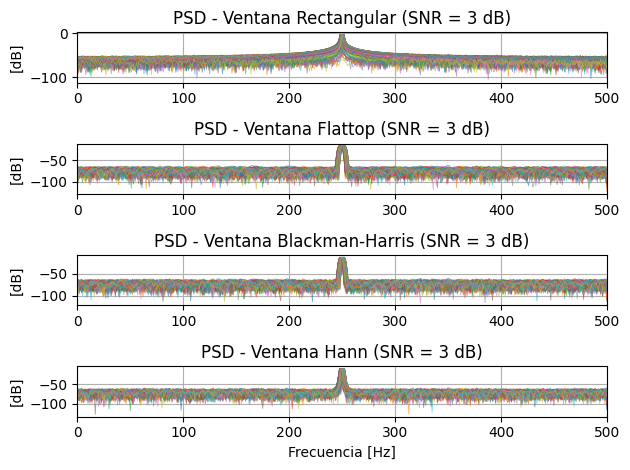

In [25]:
plt.figure (1)

plt.subplot (4, 1, 1)
plt.plot (ff, 10*np.log10(np.abs(X1_rect)**2), linewidth=0.6, alpha=0.6)
plt.title ('PSD - Ventana Rectangular (SNR = 3 dB)')
plt.ylabel ('[dB]')
plt.xlim (0, fs/2)
plt.grid (True)

plt.subplot (4, 1, 2)
plt.plot (ff, 10*np.log10(np.abs(X1_flat)**2), linewidth=0.6, alpha=0.6)
plt.title ('PSD - Ventana Flattop (SNR = 3 dB)')
plt.ylabel ('[dB]')
plt.xlim (0, fs/2)
plt.grid (True)

plt.subplot (4, 1, 3)
plt.plot (ff, 10*np.log10(np.abs(X1_bh)**2), linewidth=0.6, alpha=0.6)
plt.title ('PSD - Ventana Blackman-Harris (SNR = 3 dB)')
plt.ylabel ('[dB]')
plt.xlim (0, fs/2)
plt.grid (True)

plt.subplot (4, 1, 4)
plt.plot (ff, 10*np.log10(np.abs(X1_hann)**2), linewidth=0.6, alpha=0.6)
plt.title ('PSD - Ventana Hann (SNR = 3 dB)')
plt.xlabel ('Frecuencia [Hz]')
plt.ylabel ('[dB]')
plt.xlim (0, fs/2)
plt.grid (True)

plt.tight_layout ()
plt.show ()


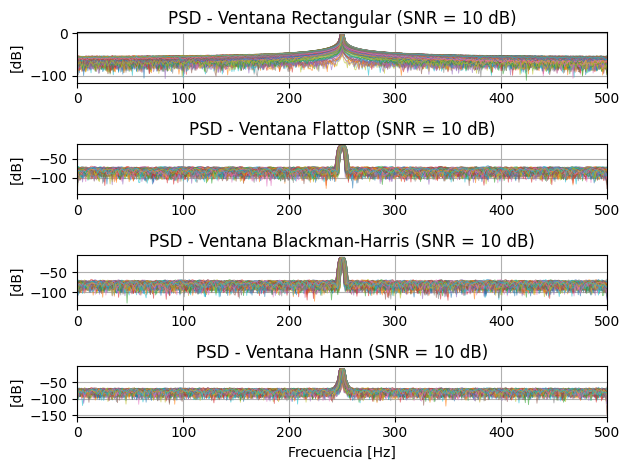

In [26]:
# ---------------------- Gráfico de PSD para señal x2 (SNR = 10 dB) ---------------------- #

plt.figure(4)

plt.subplot(4, 1, 1)
plt.plot(ff, 10*np.log10(np.abs(X2_rect)**2), linewidth=0.6, alpha=0.6)
plt.title('PSD - Ventana Rectangular (SNR = 10 dB)')
plt.ylabel('[dB]')
plt.xlim(0, fs/2)
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(ff, 10*np.log10(np.abs(X2_flat)**2), linewidth=0.6, alpha=0.6)
plt.title('PSD - Ventana Flattop (SNR = 10 dB)')
plt.ylabel('[dB]')
plt.xlim(0, fs/2)
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(ff, 10*np.log10(np.abs(X2_bh)**2), linewidth=0.6, alpha=0.6)
plt.title('PSD - Ventana Blackman-Harris (SNR = 10 dB)')
plt.ylabel('[dB]')
plt.xlim(0, fs/2)
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(ff, 10*np.log10(np.abs(X2_hann)**2), linewidth=0.6, alpha=0.6)
plt.title('PSD - Ventana Hann (SNR = 10 dB)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('[dB]')
plt.xlim(0, fs/2)
plt.grid(True)

plt.tight_layout()
plt.show()

Se generaron 200 realizaciones de señales sinusoidales con frecuencia aleatoria centrada en f_0 , contaminadas con ruido blanco gaussiano para dos niveles de SNR: 3 dB y 10 dB. Se aplicaron cuatro ventanas de análisis (Rectangular, Flattop, Blackman-Harris y Hann) y se calculó la DFT para observar el comportamiento espectral.

Observaciones para SNR = 3 dB
- Ruido dominante: El espectro presenta mayor dispersión, dificultando la localización precisa del pico espectral.
- Ventana Rectangular: Genera alto desparramo espectral, lo que se traduce en mayor sesgo y varianza.
- Ventanas suavizadas (Flattop, BH, Hann): Mejoran la supresión de lóbulos laterales, reduciendo interferencias espectrales. Sin embargo, el bajo SNR limita la precisión.
- Varianza elevada: La dispersión de los estimadores es significativa, reflejando la sensibilidad al ruido.

Observaciones para SNR = 10 dB
- Ruido reducido: El espectro es más limpio, con picos más definidos y menor fondo de ruido.
- Mejor desempeño general: Todos los estimadores presentan menor sesgo y varianza.
- Ventana Blackman-Harris: Se destaca por su bajo sesgo y excelente supresión de interferencias.
- Ventana Flattop: Aunque diseñada para estimación de amplitud, también muestra buena estabilidad en frecuencia.
- Ventana Hann: Ofrece un buen compromiso entre resolución y robustez.



# Calculo de estimadores en amplitud y frecuenicia 

In [27]:
# --------------------- Estimadores de amplitud de la señal x1 (SNR = 3dB) --------------------- #


ax1_rect = 2*np.max(np.abs(X1_rect_zp), axis=0) / np.mean(w_rect)
ax1_flat = 2*np.max(np.abs(X1_flat_zp), axis=0) / np.mean(w_flat)
ax1_bh   = 2*np.max(np.abs(X1_bh_zp),   axis=0) / np.mean(w_bh)
ax1_hann = 2*np.max(np.abs(X1_hann_zp), axis=0) / np.mean(w_hann)

sesgo_ax1_rect = np.mean (ax1_rect) - amp_0 
sesgo_ax1_flat = np.mean (ax1_flat) - amp_0
sesgo_ax1_bh   = np.mean (ax1_bh)   - amp_0
sesgo_ax1_hann = np.mean (ax1_hann) - amp_0

var_ax1_rect = np.var (ax1_rect) 
var_ax1_flat = np.var (ax1_flat) 
var_ax1_bh   = np.var (ax1_bh)
var_ax1_hann = np.var (ax1_hann)


# --------------------- Estimadores de amplitud de la señal x2 (SNR = 10dB) --------------------- #


ax2_rect = 2*np.max(np.abs(X2_rect_zp), axis=0) / np.mean(w_rect)
ax2_flat = 2*np.max(np.abs(X2_flat_zp), axis=0) / np.mean(w_flat)
ax2_bh   = 2*np.max(np.abs(X2_bh_zp),   axis=0) / np.mean(w_bh)
ax2_hann = 2*np.max(np.abs(X2_hann_zp), axis=0) / np.mean(w_hann)

sesgo_ax2_rect = np.mean (ax2_rect) - amp_0
sesgo_ax2_flat = np.mean (ax2_flat) - amp_0
sesgo_ax2_bh   = np.mean (ax2_bh)   - amp_0
sesgo_ax2_hann = np.mean (ax2_hann) - amp_0

var_ax2_rect = np.var (ax2_rect)
var_ax2_flat = np.var (ax2_flat)
var_ax2_bh   = np.var (ax2_bh)
var_ax2_hann = np.var (ax2_hann)


# --------------------- Estimadores de frecuencia de la señal x1 (SNR = 3dB) --------------------- #


fx1_rect = np.argmax ((np.abs(X1_rect[0:N//2, :])), axis=0)
fx1_flat = np.argmax ((np.abs(X1_flat[0:N//2, :])), axis=0)
fx1_bh   = np.argmax ((np.abs(X1_bh[0:N//2, :])),   axis=0)
fx1_hann = np.argmax ((np.abs(X1_hann[0:N//2, :])), axis=0)

sesgo_fx1_rect = np.mean (fx1_rect - frec_mat[N//4, :]) # ahora mi valor de frecuencia conocido ya no está fijo, debo barrer todas las realizaciones
sesgo_fx1_flat = np.mean (fx1_flat - frec_mat[N//4, :])
sesgo_fx1_bh   = np.mean (fx1_bh   - frec_mat[N//4, :])
sesgo_fx1_hann = np.mean (fx1_hann - frec_mat[N//4, :])

var_fx1_rect = np.var (fx1_rect)
var_fx1_flat = np.var (fx1_flat)
var_fx1_bh   = np.var (fx1_bh)
var_fx1_hann = np.var (fx1_hann)


# --------------------- Estimadores de frecuencia de la señal x2 (SNR = 10dB) --------------------- #


fx2_rect = np.argmax ((np.abs(X2_rect[0:N//2, :])), axis=0)
fx2_flat = np.argmax ((np.abs(X2_flat[0:N//2, :])), axis=0)
fx2_bh   = np.argmax ((np.abs(X2_bh  [0:N//2, :])), axis=0)
fx2_hann = np.argmax ((np.abs(X2_hann[0:N//2, :])), axis=0)

sesgo_fx2_rect = np.mean (fx2_rect - N//4)
sesgo_fx2_flat = np.mean (fx2_flat - N//4)
sesgo_fx2_bh   = np.mean (fx2_bh   - N//4)
sesgo_fx2_hann = np.mean (fx2_hann - N//4)

var_fx2_rect = np.var (fx2_rect)
var_fx2_flat = np.var (fx2_flat)
var_fx2_bh   = np.var (fx2_bh)
var_fx2_hann = np.var (fx2_hann)


# ------------------------------------- Tablas ------------------------------------- #

print("\n")
print("========== Estimaciones para Señal x1 ==========")
print("{:<18} | {:>10} | {:>12}".format("Ventana", "Sesgo", "Varianza"))
print("-"*45)
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Rectangular", sesgo_ax1_rect, var_ax1_rect))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Flattop", sesgo_ax1_flat, var_ax1_flat))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_ax1_bh, var_ax1_bh))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Hann", sesgo_ax1_hann, var_ax1_hann))

print("\n")
print("========== Estimaciones para Señal x2 ==========")
print("{:<18} | {:>10} | {:>12}".format("Ventana", "Sesgo", "Varianza"))
print("-"*45)
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Rectangular", sesgo_ax2_rect, var_ax2_rect))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Flattop", sesgo_ax2_flat, var_ax2_flat))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_ax2_bh, var_ax2_bh))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Hann", sesgo_ax2_hann, var_ax2_hann))


# --------------------- Tabla de estimación de frecuencia --------------------- #

print("\n")
print("========== Estimación de Frecuencia para Señal x1 (SNR = 3 dB) ==========")
print("{:<18} | {:>12} | {:>12}".format("Ventana", "Sesgo ", "Varianza "))
print("-"*46)
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Rectangular", sesgo_fx1_rect, var_fx1_rect))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Flattop", sesgo_fx1_flat, var_fx1_flat))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_fx1_bh, var_fx1_bh))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Hann", sesgo_fx1_hann, var_fx1_hann))

print("\n")
print("========== Estimación de Frecuencia para Señal x2 (SNR = 10 dB) ==========")
print("{:<18} | {:>12} | {:>12}".format("Ventana", "Sesgo ", "Varianza "))
print("-"*46)
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Rectangular", sesgo_fx2_rect, var_fx2_rect))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Flattop", sesgo_fx2_flat, var_fx2_flat))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_fx2_bh, var_fx2_bh))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Hann", sesgo_fx2_hann, var_fx2_hann))





========== Estimaciones para Señal x1 ==========
Ventana            |      Sesgo |     Varianza
---------------------------------------------
Rectangular        |  -0.002734 |   0.00000420
Flattop            |   0.000490 |   0.00000264
Blackman-Harris    |  -0.000468 |   0.00000157
Hann               |  -0.000780 |   0.00000153


========== Estimaciones para Señal x2 ==========
Ventana            |      Sesgo |     Varianza
---------------------------------------------
Rectangular        |  -0.002673 |   0.00000341
Flattop            |   0.000417 |   0.00000053
Blackman-Harris    |  -0.000456 |   0.00000041
Hann               |  -0.000767 |   0.00000065


========== Estimación de Frecuencia para Señal x1 (SNR = 3 dB) ==========
Ventana            |       Sesgo  |    Varianza 
----------------------------------------------
Rectangular        |    -0.006555 |   1.64640000
Flattop            |    -0.001555 |   1.66077500
Blackman-Harris    |    -0.011555 |   1.63197500
Hann             

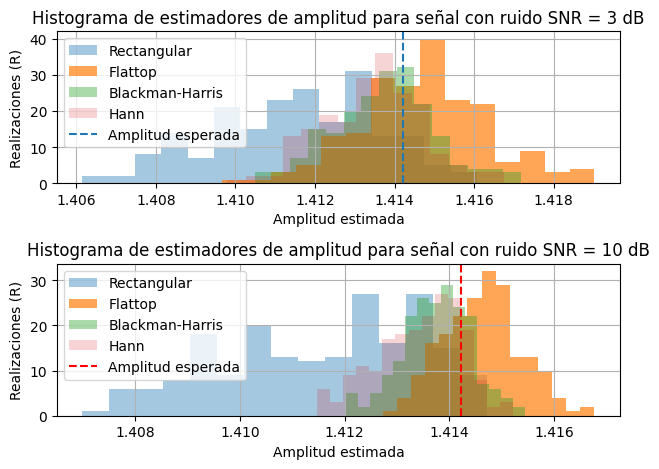

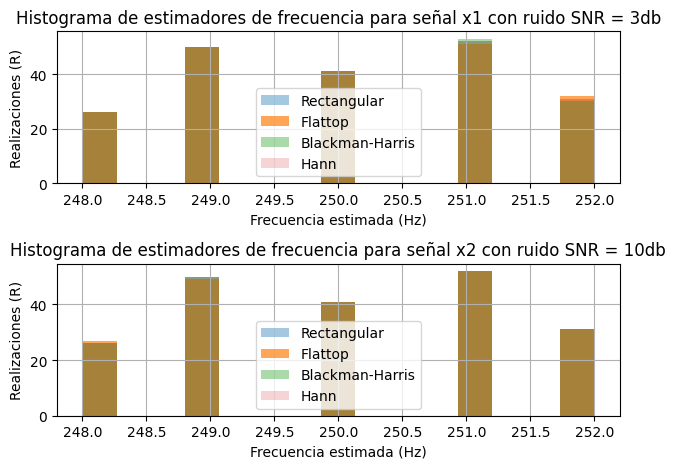

In [28]:
# --------------------------- Ploteos estimadores de amplitud --------------------------- #


plt.figure (2)

plt.subplot (2, 1, 1)
plt.hist (ax1_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (ax1_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (ax1_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (ax1_hann, bins=15, alpha=0.2, label='Hann')
plt.axvline (x=amp_0, linestyle='--', label='Amplitud esperada')
plt.title ('Histograma de estimadores de amplitud para señal con ruido SNR = 3 dB')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Amplitud estimada')
plt.grid (True)
plt.legend ()

plt.subplot (2, 1, 2)
plt.hist (ax2_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (ax2_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (ax2_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (ax2_hann, bins=15, alpha=0.2, label='Hann')
plt.axvline (x=amp_0, linestyle='--', color='red', label='Amplitud esperada')
plt.title ('Histograma de estimadores de amplitud para señal con ruido SNR = 10 dB')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Amplitud estimada')
plt.grid (True)
plt.legend ()

plt.tight_layout ()
plt.show ()

# --------------------------- Ploteos de estimadores de frecuencia --------------------------- #


plt.figure (3)

plt.subplot (2, 1, 1)
plt.hist (fx1_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (fx1_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (fx1_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (fx1_hann, bins=15, alpha=0.2, label='Hann')
plt.title ('Histograma de estimadores de frecuencia para señal x1 con ruido SNR = 3db')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Frecuencia estimada (Hz)')
plt.legend ()
plt.grid (True)

plt.subplot (2, 1, 2)
plt.hist (fx2_rect, bins=15,alpha=0.4, label='Rectangular')
plt.hist (fx2_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (fx2_bh, bins=15,alpha=0.4, label='Blackman-Harris')
plt.hist (fx2_hann, bins=15, alpha=0.2, label='Hann')
plt.title ('Histograma de estimadores de frecuencia para señal x2 con ruido SNR = 10db')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Frecuencia estimada (Hz)')
plt.legend ()
plt.grid (True)

plt.tight_layout ()
plt.show ()


  ## Análisis de estimadores de amplitud
SNR = 3 dB

Rectangular: muestra el mayor sesgo y la mayor varianza. La ausencia de atenuación de lóbulos laterales hace que el ruido espectral afecte más la estimación del pico.

Flattop: presenta el sesgo más bajo, tal como se espera de esta ventana diseñada para estimar amplitudes con precisión.

Blackman–Harris: logra una varianza baja y sesgo pequeño gracias a su fuerte supresión de lóbulos laterales.

Hann: mejora claramente respecto a la rectangular, con varianza baja y un comportamiento estable.

SNR = 10 dB

El aumento del SNR reduce significativamente la varianza en todos los casos.

Flattop sigue siendo la ventana con menor sesgo.

Blackman–Harris y Hann mantienen varianzas muy bajas.

Rectangular mejora respecto a 3 dB, pero sigue siendo la menos confiable.

Conclusión amplitud

A bajo SNR, el tipo de ventana influye de forma importante.

A mayor SNR, todas mejoran, pero Flattop, Blackman–Harris y Hann son claramente superiores a la rectangular para estimar amplitudes.

Las métricas coinciden con lo esperado teóricamente: ventanas más suaves → menor varianza.

 ## Análisis de estimadores de frecuencia
SNR = 3 dB

Todas las ventanas muestran varianzas muy similares, cercanas a 1.6.
Esto no se debe a las ventanas, sino a que la frecuencia verdadera cambia ±2 Hz entre realizaciones, generando una dispersión que domina sobre el ruido.

El sesgo es pequeño en todas las ventanas (del orden de 0.01–0.02 bins).

No se observan diferencias fuertes entre ventanas en las métricas, porque el error está gobernado por la variación aleatoria de frecuencia.

SNR = 10 dB

El comportamiento es prácticamente el mismo que con 3 dB.
Al mejorar el SNR, el ruido baja, pero la variación de ±2 Hz en la frecuencia verdadera sigue dominando el error.

Por eso, los valores de sesgo y varianza permanecen casi constantes entre ventanas y entre niveles de SNR.

Conclusión frecuencia

En este experimento, la dispersión del estimador de frecuencia está dominada por la variación aleatoria de la frecuencia real (±2 Hz), no por el ruido ni por el tipo de ventana.

Por este motivo, las varianzas resultan muy similares para todas las ventanas y para ambos niveles de SNR.

Aun así, los histogramas muestran que las ventanas suavizadas (Hann y Blackman–Harris) producen distribuciones algo más concentradas, especialmente a bajo SNR, lo cual concuerda con su mejor supresión de lóbulos laterales.


## Análisis de histogramas de estimadores de frecuencia

Señal x1 – SNR = 3 dB

Los histogramas muestran que la dispersión proviene principalmente del rango aleatorio de frecuencias reales.

Rectangular: algo más dispersa, por mayor contaminación de ruido espectral.

Flattop: comportamiento razonablemente estable.

Blackman–Harris y Hann: histogramas algo más concentrados, coherentes con su supresión de lóbulos laterales.

Señal x2 – SNR = 10 dB

Al subir el SNR, los histogramas se estrechan, pero la dispersión asociada al rango ±2 Hz sigue siendo dominante.

Rectangular sigue siendo la ventana más dispersa.

Blackman–Harris mantiene la distribución más concentrada.

Hann también muestra muy buena estabilidad.

Conclusión

Los histogramas confirman que el tipo de ventana mejora la estabilidad de la estimación, pero la variación de frecuencia real entre realizaciones es el factor dominante.

Las ventanas suavizadas siguen siendo beneficiosas, especialmente Blackman–Harris y Hann.

## Conclusion final
Los resultados muestran que la ventana utilizada influye fuertemente en la estimación de amplitud: las ventanas suavizadas (Hann y Blackman–Harris) y la Flattop presentan menor sesgo y varianza que la rectangular, especialmente a bajo SNR. En la estimación de frecuencia, las varianzas resultan similares entre ventanas porque la dispersión está dominada por la variación aleatoria de la frecuencia real entre realizaciones. Aun así, las ventanas suavizadas producen histogramas ligeramente más concentrados. En conjunto, la elección de ventana es clave para la estimación de amplitud y aporta estabilidad adicional en la estimación de frecuencia.